# Cat Skin Disease Classification using CNN (Transfer Learning)



In [2]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

ModuleNotFoundError: No module named 'google'

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import os
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
import pathlib

import seaborn as sns
import pandas as pd

# Import metrics lengkap
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    precision_recall_fscore_support
)

# Konfigurasi GPU (jika tersedia)
try:
    gpus = tf.config.list_physical_devices('GPU')
    if gpus:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"GPU Detected: {len(gpus)}")
    else:
        print("No GPU detected, running on CPU")
except Exception as e:
    print(f"Error configuring GPU: {e}")

GPU Detected: 1


## 1. Dataset



In [ ]:
# Lokasi dataset di Google Drive
data_dir = pathlib.Path('/content/drive/MyDrive/CATSCKIN/CAT_SKIN_DISEASE/')

# Cek apakah direktori dataset ditemukan
if not data_dir.exists():
    print(f"WARNING: Dataset tidak ditemukan di {data_dir}. Pastikan path sudah benar.")
else:
    print(f"Dataset ditemukan di {data_dir}")

# Parameter Loader
batch_size = 32    # jumlah gambar yang diproses model sekaligus dalam training
img_height = 224   # MobileNetV2 menggunakan 224x224
img_width = 224
seed=123         # pembagian data konsisten, adil, dan bisa direproduksi.

# TRAINING (80%)
print("Training Data:")
train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=seed,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

# TEMP (20%)
print("\nTemporary Validation/Test Data:")
temp_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=seed,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

# SPLIT → VALIDATION (10%) & TESTING (10%)
val_size = len(temp_ds) // 2
val_ds = temp_ds.take(val_size)
test_ds = temp_ds.skip(val_size)

class_names = train_ds.class_names

print("\nFinal Dataset Split:")
print(f"Training   : {len(train_ds)} batch")
print(f"Validation : {len(val_ds)} batch")
print(f"Testing    : {len(test_ds)} batch")

class_names = train_ds.class_names
print(f"\nKelas yang ditemukan: {class_names}")

Dataset ditemukan di /content/drive/MyDrive/CATSCKIN/CAT_SKIN_DISEASE
Training Data:
Found 999 files belonging to 4 classes.
Using 800 files for training.

Temporary Validation/Test Data:
Found 999 files belonging to 4 classes.
Using 199 files for validation.

Final Dataset Split:
Training   : 25 batch
Validation : 3 batch
Testing    : 4 batch

Kelas yang ditemukan: ['Flea_Allergy', 'Health', 'Ringworm', 'Scabies']


## 2. Visualisasi Data

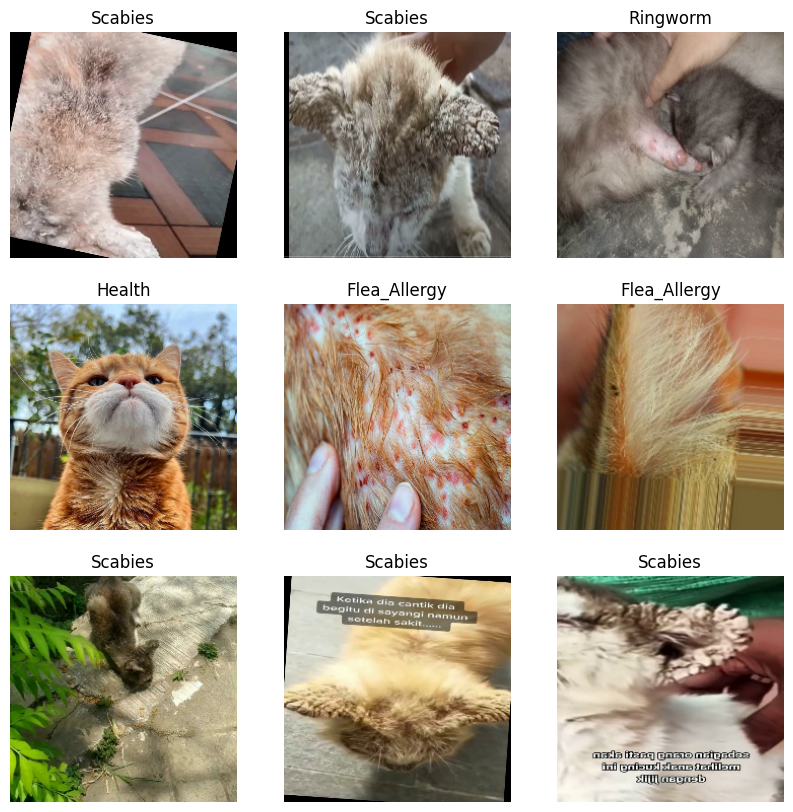

In [ ]:
plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
  for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(class_names[labels[i]])
    plt.axis("off")
plt.show()

## 3. Optimasi Performa (Prefetching)


In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

## 4. Data Augmentation


In [ ]:
data_augmentation = keras.Sequential(
  [
    layers.RandomFlip("horizontal",
                      input_shape=(img_height,
                                  img_width,
                                  3)),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
  ]
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/tf_data_layer.py:19: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


## 5. Membangun Model MobileNetV2(Transfer Learning)



In [ ]:
num_classes = len(class_names)

# Menggunakan pre-trained model MobileNetV2
base_model = tf.keras.applications.MobileNetV2(input_shape=(img_height, img_width, 3),
                                               include_top=False,
                                               weights='imagenet')

# Bekukan base model agar bobotnya tidak berubah di awal training
base_model.trainable = False

model = Sequential([
  data_augmentation,
  layers.Rescaling(1./127.5, offset=-1), # Preprocessing khusus MobileNetV2
  base_model,
  layers.GlobalAveragePooling2D(),
  layers.Dropout(0.2), # Mencegah overfitting
  layers.Dense(num_classes, activation='softmax') # Output layer
])

model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4)              │         5,124 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,263,108 (8.63 MB)

 Trainable params: 5,124 (20.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

## 6. Compile dan Training Model

In [ ]:
# Compile model
model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=['accuracy']
)

# Jumlah epoch maksimum
epochs = 20

# Callbacks
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',       # pantau loss validasi
    patience=5,               # berhenti jika 5 epoch tidak membaik
    restore_best_weights=True # kembalikan bobot terbaik
)

model_checkpoint = tf.keras.callbacks.ModelCheckpoint(
    filepath='best_model.keras',
    monitor='val_loss',       # simpan model terbaik berdasarkan val_loss
    save_best_only=True,
    verbose=1
)

callbacks = [early_stopping, model_checkpoint]

# Training model
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs,
    callbacks=callbacks
)


Epoch 1/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.3186 - loss: 1.7223
Epoch 1: val_loss improved from inf to 0.78660, saving model to best_model.keras
25/25 ━━━━━━━━━━━━━━━━━━━━ 153s 787ms/step - accuracy: 0.3229 - loss: 1.7103 - val_accuracy: 0.7500 - val_loss: 0.7866
Epoch 2/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.6553 - loss: 0.8558
Epoch 2: val_loss improved from 0.78660 to 0.54882, saving model to best_model.keras
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 81ms/step - accuracy: 0.6569 - loss: 0.8532 - val_accuracy: 0.8542 - val_loss: 0.5488
Epoch 3/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.7493 - loss: 0.6592
Epoch 3: val_loss improved from 0.54882 to 0.44668, saving model to best_model.keras
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 79ms/step - accuracy: 0.7500 - loss: 0.6574 - val_accuracy: 0.8646 - val_loss: 0.4467
Epoch 4/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.7727 - loss: 0.5553
Epoch 4: val_loss improved from 0.44668 to 0.41527, saving

## 7. Evaluasi Hasil Training

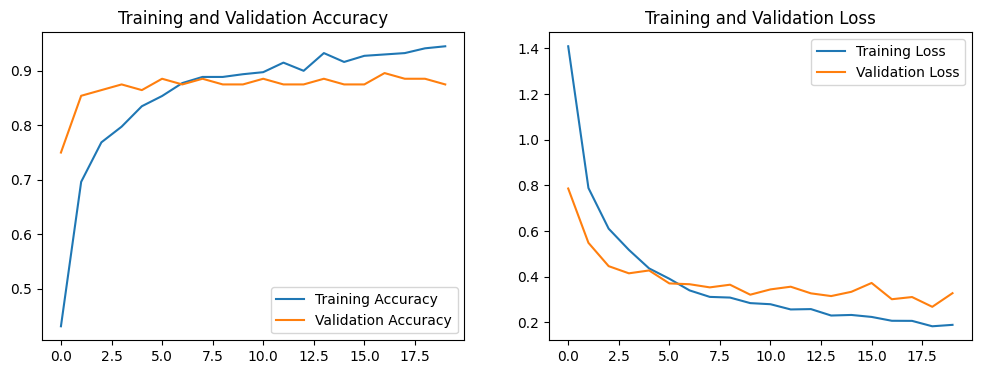

In [ ]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(len(acc))

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

## 8. Confusion Matrix & Evaluasi

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 236ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step


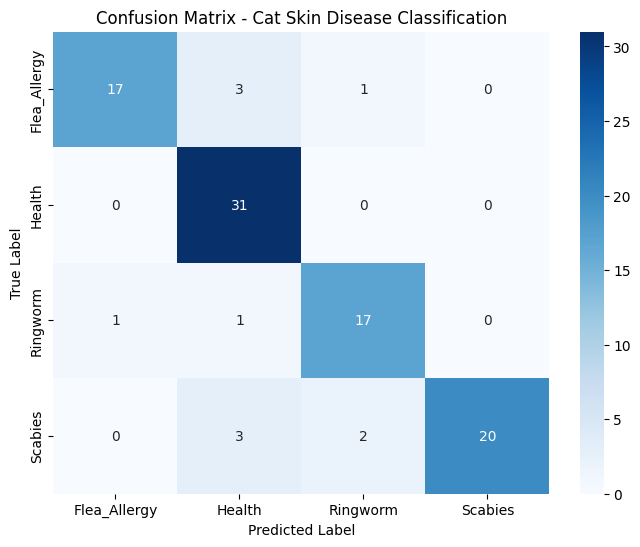

Classification Report:

              precision    recall  f1-score   support

Flea_Allergy       0.94      0.81      0.87        21
      Health       0.82      1.00      0.90        31
    Ringworm       0.85      0.89      0.87        19
     Scabies       1.00      0.80      0.89        25

    accuracy                           0.89        96
   macro avg       0.90      0.88      0.88        96
weighted avg       0.90      0.89      0.88        96

Overall Accuracy: 0.8854
Macro Precision: 0.9026
Macro Recall: 0.8761
Macro F1-score: 0.8828


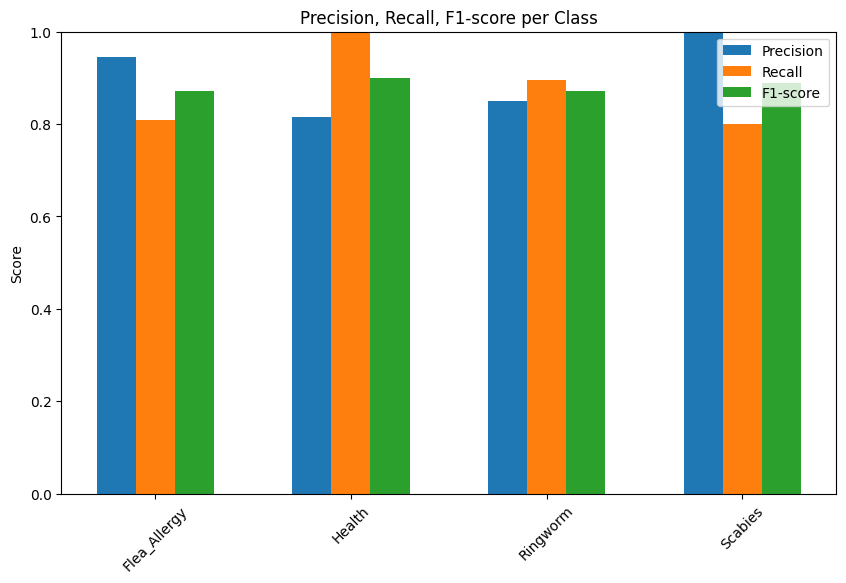

In [ ]:
y_true = []
y_pred = []

for images, labels in val_ds:
    predictions = model.predict(images)
    y_pred.extend(np.argmax(predictions, axis=1))
    y_true.extend(labels.numpy())

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - Cat Skin Disease Classification')
plt.show()

# Classification Report
print("Classification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_names))

# Precision, Recall, F1-score Macro
precision_macro = precision_score(y_true, y_pred, average='macro')
recall_macro = recall_score(y_true, y_pred, average='macro')
f1_macro = f1_score(y_true, y_pred, average='macro')
accuracy = accuracy_score(y_true, y_pred)

print(f"Overall Accuracy: {accuracy:.4f}")
print(f"Macro Precision: {precision_macro:.4f}")
print(f"Macro Recall: {recall_macro:.4f}")
print(f"Macro F1-score: {f1_macro:.4f}")

# Visualisasi Precision, Recall, F1 per kelas
precision_cls, recall_cls, f1_cls, _ = precision_recall_fscore_support(y_true, y_pred, average=None)
x = range(len(class_names))

plt.figure(figsize=(10,6))
plt.bar(x, precision_cls, width=0.2, label='Precision', align='center')
plt.bar([i+0.2 for i in x], recall_cls, width=0.2, label='Recall', align='center')
plt.bar([i+0.4 for i in x], f1_cls, width=0.2, label='F1-score', align='center')
plt.xticks([i+0.2 for i in x], class_names, rotation=45)
plt.ylim(0,1)
plt.ylabel("Score")
plt.title("Precision, Recall, F1-score per Class")
plt.legend()
plt.show()


## 9. Fine Tuning (Opsional)


In [ ]:
# Unfreeze base model
base_model.trainable = True

# Fine-tune dari layer ke-100 ke atas
fine_tune_at = 100
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

# Compile ulang dengan learning rate rendah
model.compile(loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
              optimizer = tf.keras.optimizers.Adam(learning_rate=1e-5),
              metrics=['accuracy'])

print("Mulai Fine-Tuning...")
history_fine = model.fit(train_ds,
                         epochs=10, # Tambahan epoch
                         initial_epoch=history.epoch[-1],
                         validation_data=val_ds,
                         callbacks=callbacks)

Mulai Fine-Tuning...


## 10. Prediksi Gambar Baru


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


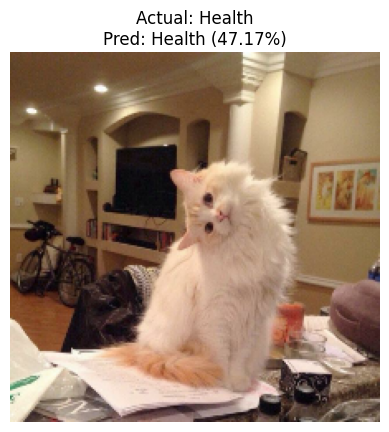

In [ ]:
# Contoh prediksi (ambil 1 gambar dari val_ds)
for images, labels in val_ds.take(1):
    img_array = images[0].numpy()
    actual_label = class_names[labels[0]]

    img_batch = np.expand_dims(img_array, 0)
    predictions = model.predict(img_batch)
    score = tf.nn.softmax(predictions[0])

    plt.imshow(img_array.astype("uint8"))
    plt.title(f"Actual: {actual_label}\nPred: {class_names[np.argmax(score)]} ({100 * np.max(score):.2f}%)")
    plt.axis("off")
    plt.show()

In [ ]:
# Simpan model final
model.save('cat_skin_disease_model_final.h5')
print("Model berhasil disimpan!")

Model berhasil disimpan!


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import os
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
import pathlib

import seaborn as sns
import pandas as pd

# Import metrics lengkap
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    precision_recall_fscore_support
)

# Konfigurasi GPU (jika tersedia)
try:
    gpus = tf.config.list_physical_devices('GPU')
    if gpus:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"GPU Detected: {len(gpus)}")
    else:
        print("No GPU detected, running on CPU")
except Exception as e:
    print(f"Error configuring GPU: {e}")

GPU Detected: 1


## Persiapan Dataset

In [ ]:
# Lokasi dataset di Google Drive
data_dir = pathlib.Path('/content/drive/MyDrive/CATSCKIN/CAT SKIN DISEASE/')

# Cek apakah direktori dataset ditemukan
if not data_dir.exists():
    print(f"WARNING: Dataset tidak ditemukan di {data_dir}. Pastikan path sudah benar.")
else:
    print(f"Dataset ditemukan di {data_dir}")

# Parameter Loader
batch_size = 32
img_height = 240  # EfficientNetB1 optimal pada 240x240
img_width = 240

# Lokasi dataset di Google Drive
data_dir = pathlib.Path('/content/drive/MyDrive/CATSCKIN/CAT_SKIN_DISEASE/')

# Cek apakah direktori dataset ditemukan
if not data_dir.exists():
    print(f"WARNING: Dataset tidak ditemukan di {data_dir}. Pastikan path sudah benar.")
else:
    print(f"Dataset ditemukan di {data_dir}")

# Parameter Loader
batch_size = 32    # jumlah gambar yang diproses model sekaligus dalam training
img_height = 224   # MobileNetV2 menggunakan 224x224
img_width = 224
seed=123         # pembagian data konsisten, adil, dan bisa direproduksi.

# TRAINING (80%)
print("Training Data:")
train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=seed,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

# TEMP (20%)
print("\nTemporary Validation/Test Data:")
temp_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=seed,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

# SPLIT → VALIDATION (10%) & TESTING (10%)
val_size = len(temp_ds) // 2
val_ds = temp_ds.take(val_size)
test_ds = temp_ds.skip(val_size)

class_names = train_ds.class_names

print("\nFinal Dataset Split:")
print(f"Training   : {len(train_ds)} batch")
print(f"Validation : {len(val_ds)} batch")
print(f"Testing    : {len(test_ds)} batch")

class_names = train_ds.class_names
print(f"\nKelas yang ditemukan: {class_names}")

Dataset ditemukan di /content/drive/MyDrive/CATSCKIN/CAT_SKIN_DISEASE
Training Data:
Found 999 files belonging to 4 classes.
Using 800 files for training.

Temporary Validation/Test Data:
Found 999 files belonging to 4 classes.
Using 199 files for validation.

Final Dataset Split:
Training   : 25 batch
Validation : 3 batch
Testing    : 4 batch

Kelas yang ditemukan: ['Flea_Allergy', 'Health', 'Ringworm', 'Scabies']


## Visualisasi Data

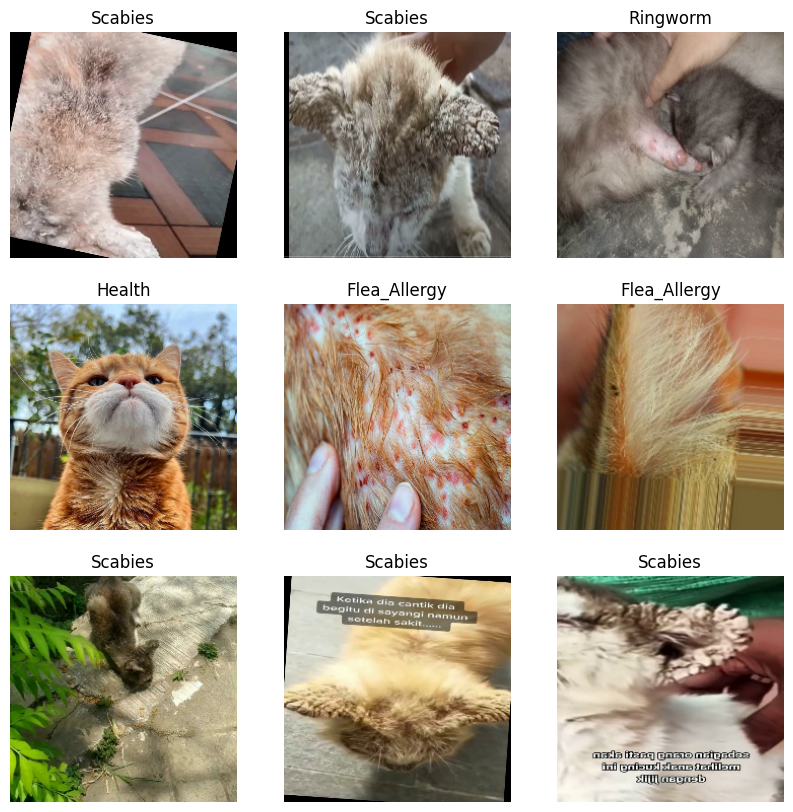

In [ ]:
plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
  for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(class_names[labels[i]])
    plt.axis("off")
plt.show()

## Optimasi Performa (Prefetching)

In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

## Data Augmentation

In [ ]:
data_augmentation = keras.Sequential(
  [
    layers.RandomFlip("horizontal",
                      input_shape=(img_height,
                                  img_width,
                                  3)),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
  ]
)

layers.RandomRotation(0.05),
layers.RandomZoom(0.05),

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/tf_data_layer.py:19: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


(<RandomZoom name=random_zoom_2, built=False>,)

## Membangun Model  EfficientNetB1 (Transfer Learning)


In [ ]:
num_classes = len(class_names)

# Menggunakan pre-trained model EfficientNetB1
# Note: EfficientNetB1 mengharapkan input 240x240 dan nilai pixel [0, 255]
base_model = tf.keras.applications.EfficientNetB1(input_shape=(img_height, img_width, 3),
                                                  include_top=False,
                                                  weights='imagenet')

# Bekukan base model agar bobotnya tidak berubah di awal training
base_model.trainable = False

model = Sequential([
  data_augmentation,
  # Layer Rescaling dihapus karena EfficientNetB1 sudah memiliki preprocessing internal
  base_model,
  layers.GlobalAveragePooling2D(),
  layers.Dropout(0.2), # Mencegah overfitting
  layers.Dense(num_classes, activation='softmax') # Output layer
])

model.summary()

27018416/27018416 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_2 (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb1 (Functional)     │ (None, 7, 7, 1280)     │     6,575,239 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         5,124 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,580,363 (25.10 MB)

 Trainable params: 5,124 (20.02 KB)

 Non-trainable params: 6,575,239 (25.08 MB)

## Compile dan Training Model

In [ ]:
# Compile model
model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=['accuracy']
)

# Jumlah epoch maksimum
epochs = 20

# Callbacks
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',       # pantau loss validasi
    patience=5,               # berhenti jika 5 epoch tidak membaik
    restore_best_weights=True # kembalikan bobot terbaik
)

model_checkpoint = tf.keras.callbacks.ModelCheckpoint(
    filepath='best_model.keras',
    monitor='val_loss',       # simpan model terbaik berdasarkan val_loss
    save_best_only=True,
    verbose=1
)

callbacks = [early_stopping, model_checkpoint]

# Training model
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs,
    callbacks=callbacks
)

Epoch 1/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step - accuracy: 0.3977 - loss: 1.2887
Epoch 1: val_loss improved from inf to 0.70175, saving model to best_model.keras
25/25 ━━━━━━━━━━━━━━━━━━━━ 29s 346ms/step - accuracy: 0.4030 - loss: 1.2819 - val_accuracy: 0.7917 - val_loss: 0.7017
Epoch 2/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step - accuracy: 0.7647 - loss: 0.7395
Epoch 2: val_loss improved from 0.70175 to 0.49503, saving model to best_model.keras
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 168ms/step - accuracy: 0.7654 - loss: 0.7359 - val_accuracy: 0.8646 - val_loss: 0.4950
Epoch 3/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step - accuracy: 0.8090 - loss: 0.5393
Epoch 3: val_loss improved from 0.49503 to 0.41245, saving model to best_model.keras
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 154ms/step - accuracy: 0.8096 - loss: 0.5380 - val_accuracy: 0.8958 - val_loss: 0.4125
Epoch 4/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step - accuracy: 0.8564 - loss: 0.4396
Epoch 4: val_loss improved from 0.41245 to 0.38318, s

## Evaluasi Hasil Training

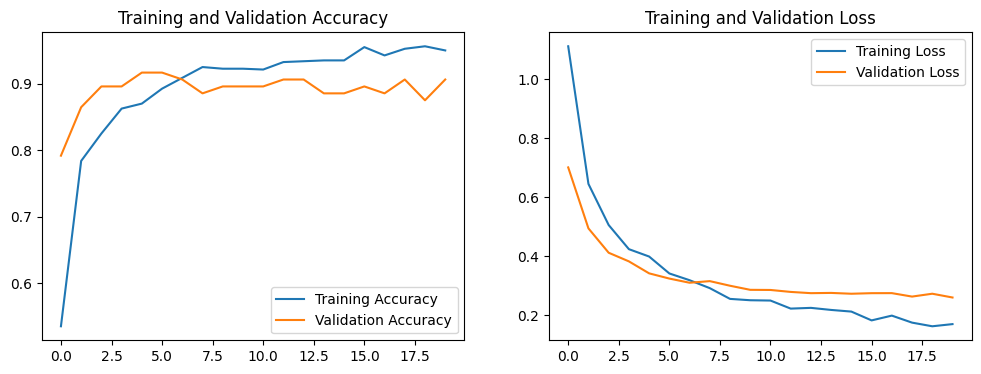

In [ ]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(len(acc))

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

## Confusion Matrix & Evaluasi

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step


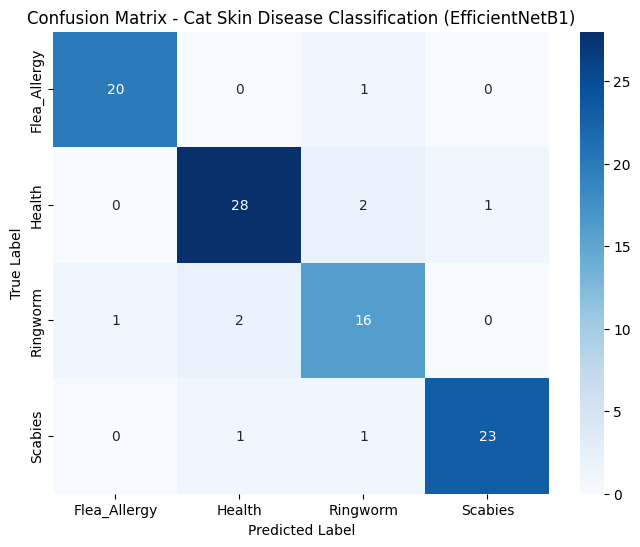

Classification Report:

              precision    recall  f1-score   support

Flea_Allergy       0.95      0.95      0.95        21
      Health       0.90      0.90      0.90        31
    Ringworm       0.80      0.84      0.82        19
     Scabies       0.96      0.92      0.94        25

    accuracy                           0.91        96
   macro avg       0.90      0.90      0.90        96
weighted avg       0.91      0.91      0.91        96

Overall Accuracy: 0.9062
Macro Precision: 0.9035
Macro Recall: 0.9044
Macro F1-score: 0.9037


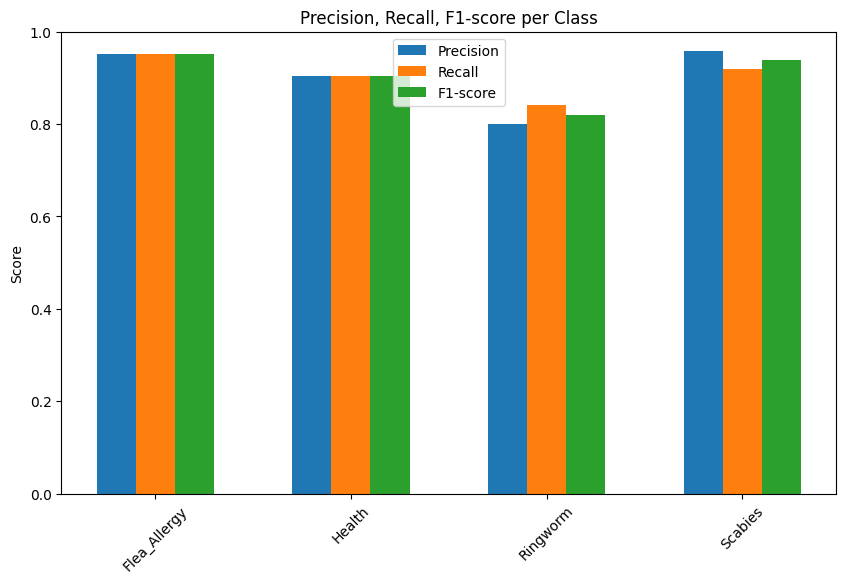

In [ ]:
y_true = []
y_pred = []

for images, labels in val_ds:
    predictions = model.predict(images)
    y_pred.extend(np.argmax(predictions, axis=1))
    y_true.extend(labels.numpy())

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - Cat Skin Disease Classification (EfficientNetB1)')
plt.show()

# Classification Report
print("Classification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_names))

# Precision, Recall, F1-score Macro
precision_macro = precision_score(y_true, y_pred, average='macro')
recall_macro = recall_score(y_true, y_pred, average='macro')
f1_macro = f1_score(y_true, y_pred, average='macro')
accuracy = accuracy_score(y_true, y_pred)

print(f"Overall Accuracy: {accuracy:.4f}")
print(f"Macro Precision: {precision_macro:.4f}")
print(f"Macro Recall: {recall_macro:.4f}")
print(f"Macro F1-score: {f1_macro:.4f}")

# Visualisasi Precision, Recall, F1 per kelas
precision_cls, recall_cls, f1_cls, _ = precision_recall_fscore_support(y_true, y_pred, average=None)
x = range(len(class_names))

plt.figure(figsize=(10,6))
plt.bar(x, precision_cls, width=0.2, label='Precision', align='center')
plt.bar([i+0.2 for i in x], recall_cls, width=0.2, label='Recall', align='center')
plt.bar([i+0.4 for i in x], f1_cls, width=0.2, label='F1-score', align='center')
plt.xticks([i+0.2 for i in x], class_names, rotation=45)
plt.ylim(0,1)
plt.ylabel("Score")
plt.title("Precision, Recall, F1-score per Class")
plt.legend()
plt.show()

## Fine Tuning (Opsional)

In [ ]:
# Unfreeze base model
base_model.trainable = True

# Fine-tune dari layer ke-100 ke atas (sesuaikan jika perlu)
fine_tune_at = 100
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

# Compile ulang dengan learning rate rendah
model.compile(loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
              optimizer = tf.keras.optimizers.Adam(learning_rate=1e-5),
              metrics=['accuracy'])

print("Mulai Fine-Tuning...")
history_fine = model.fit(train_ds,
                         epochs=10, # Tambahan epoch
                         initial_epoch=history.epoch[-1],
                         validation_data=val_ds,
                         callbacks=callbacks)

Mulai Fine-Tuning...


In [ ]:
# Simpan model final dalam format .keras (Recommended)
model.save('efficientnetb1_cat_skin_disease_final.keras')
print("Model berhasil disimpan sebagai efficientnetb1_cat_skin_disease_final.keras!")

Model berhasil disimpan sebagai efficientnetb1_cat_skin_disease_final.keras!


# HASIL PERBANDINGAN MODEL MobileNetV2 DAN EfficientNetB1

In [ ]:
models = ['MobileNetV2', 'EfficientNetB1']
accuracy = [0.8854, 0.9062]
precision = [0.9026, 0.9035]
recall = [0.8761, 0.9044]
f1 = [0.8828, 0.9037]

df_perbandingan = pd.DataFrame({
    'Model': models,
    'Accuracy': accuracy,
    'Precision (Macro)': precision,
    'Recall (Macro)': recall,
    'F1-score (Macro)': f1
})

df_perbandingan


,Model,Accuracy,Precision (Macro),Recall (Macro),F1-score (Macro)
0,MobileNetV2,0.8854,0.9026,0.8761,0.8828
1,EfficientNetB1,0.9062,0.9035,0.9044,0.9037


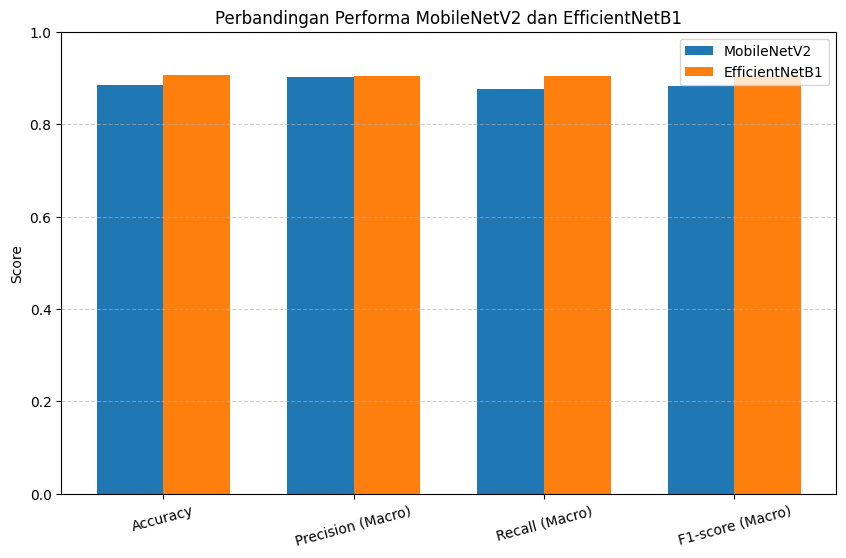

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

metrics = ['Accuracy', 'Precision (Macro)', 'Recall (Macro)', 'F1-score (Macro)']

x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(10,6))

plt.bar(x - width/2, df_perbandingan.iloc[0, 1:], width, label='MobileNetV2')
plt.bar(x + width/2, df_perbandingan.iloc[1, 1:], width, label='EfficientNetB1')

plt.xticks(x, metrics, rotation=15)
plt.ylim(0, 1)
plt.ylabel('Score')
plt.title('Perbandingan Performa MobileNetV2 dan EfficientNetB1')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.show()
